<a href="https://colab.research.google.com/github/thrishaa-112/Machine-Learning/blob/main/Loan_Approval_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix


In [ ]:
df = pd.read_csv("/content/loan approval dataset.csv")

In [ ]:
print(df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                  0         128               360   
1             4583               1508         128               360   
2             3000                  0          66               360   
3             2583               2358         120               360   
4             6000                  0         141               360   

   Credit_History Property_Area Loan_Status  
0               1         Urban           Y  
1               1         Rural           N  
2               1   

In [ ]:
df.fillna(method='ffill', inplace=True)


/tmp/ipykernel_214/4002983762.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
le = LabelEncoder()
cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for col in cols:
    df[col] = le.fit_transform(df[col])


In [ ]:
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

In [ ]:
df.drop('Loan_ID', axis=1, inplace=True)

In [ ]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']
print(y.value_counts())

Loan_Status
1    11
0     4
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6666666666666666


In [ ]:
print("\nEnter details for loan prediction:")

gender = int(input("Gender (Male=1, Female=0): "))
married = int(input("Married (Yes=1, No=0): "))
dependents = int(input("Dependents (0,1,2,3): "))
education = int(input("Education (Graduate=1, Not Graduate=0): "))
self_employed = int(input("Self Employed (Yes=1, No=0): "))
app_income = float(input("Applicant Income: "))
coapp_income = float(input("Coapplicant Income: "))
loan_amount = float(input("Loan Amount: "))
loan_term = float(input("Loan Term: "))
credit_history = int(input("Credit History (1=Good, 0=Bad): "))
property_area = int(input("Property Area (Urban=2, Semiurban=1, Rural=0): "))

user_data = np.array([[gender, married, dependents, education, self_employed,
                       app_income, coapp_income, loan_amount,
                       loan_term, credit_history, property_area]])

prediction = model.predict(user_data)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Not Approved")



Enter details for loan prediction:
Gender (Male=1, Female=0): 0
Married (Yes=1, No=0): 0
Dependents (0,1,2,3): 2
Education (Graduate=1, Not Graduate=0): 1
Self Employed (Yes=1, No=0): 1
Applicant Income: 14000
Coapplicant Income: 30000
Loan Amount: 600000
Loan Term: 5
Credit History (1=Good, 0=Bad): 1
Property Area (Urban=2, Semiurban=1, Rural=0): 2
Loan Approved


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


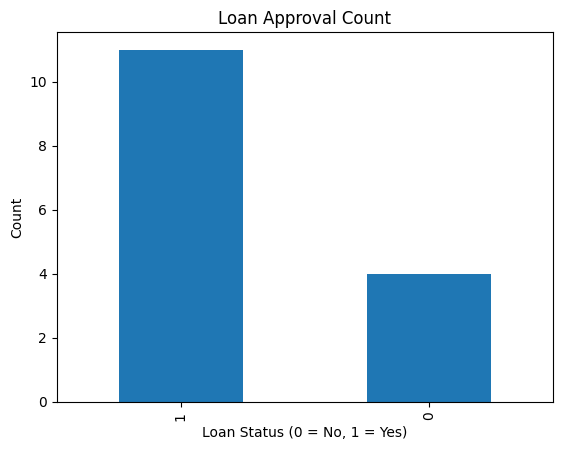

In [ ]:
df['Loan_Status'].value_counts().plot(kind='bar')
plt.title("Loan Approval Count")
plt.xlabel("Loan Status (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


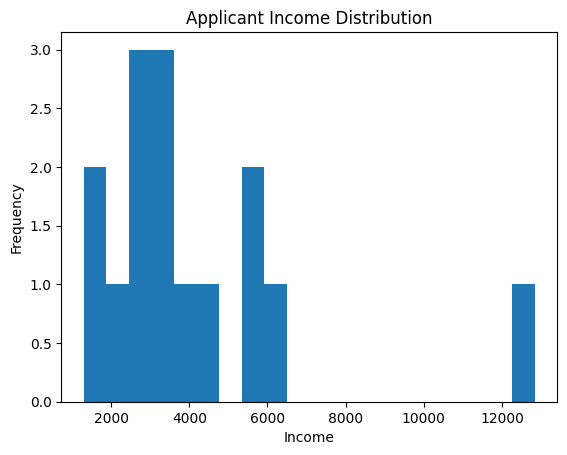

In [ ]:
plt.hist(df['ApplicantIncome'], bins=20)
plt.title("Applicant Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

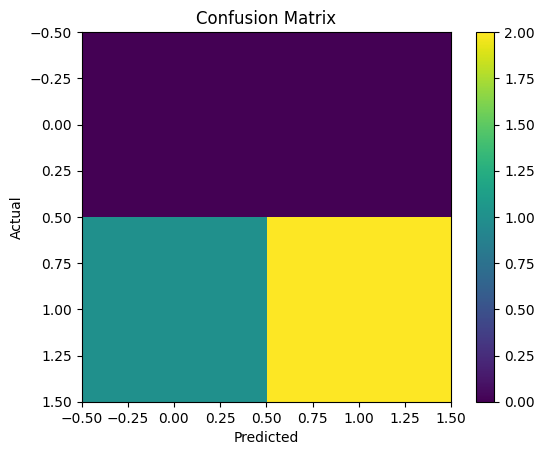

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()